# Predicting Health Outcomes of Horses: A Data-Driven Approach

## Introduction  
This project focuses on predicting the health outcomes of horses by analyzing various medical indicators. Leveraging synthetic data, we aim to refine our machine learning and data science skills through experimentation with diverse modeling and feature engineering techniques. The dataset can be downloaded from the [Kaggle Playground Series Season 3, Episode 22](https://www.kaggle.com/competitions/playground-series-s3e22/data).


In [2]:
import pandas as pd
import numpy as np

In [4]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [6]:
train.head()

,id,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data,outcome
0,0,yes,adult,530001,38.1,132.0,24.0,cool,reduced,dark_cyanotic,...,57.0,8.5,serosanguious,3.4,yes,2209,0,0,no,died
1,1,yes,adult,533836,37.5,88.0,12.0,cool,normal,pale_cyanotic,...,33.0,64.0,serosanguious,2.0,yes,2208,0,0,no,euthanized
2,2,yes,adult,529812,38.3,120.0,28.0,cool,reduced,pale_pink,...,37.0,6.4,serosanguious,3.4,yes,5124,0,0,no,lived
3,3,yes,adult,5262541,37.1,72.0,30.0,cold,reduced,pale_pink,...,53.0,7.0,cloudy,3.9,yes,2208,0,0,yes,lived
4,4,no,adult,5299629,38.0,52.0,48.0,normal,normal,normal_pink,...,47.0,7.3,cloudy,2.6,no,0,0,0,yes,lived


In [10]:
train.isna().sum()

id                         0
surgery                    0
age                        0
hospital_number            0
rectal_temp                0
pulse                      0
respiratory_rate           0
temp_of_extremities       39
peripheral_pulse          60
mucous_membrane           21
capillary_refill_time      6
pain                      44
peristalsis               20
abdominal_distention      23
nasogastric_tube          80
nasogastric_reflux        21
nasogastric_reflux_ph      0
rectal_exam_feces        190
abdomen                  213
packed_cell_volume         0
total_protein              0
abdomo_appearance         48
abdomo_protein             0
surgical_lesion            0
lesion_1                   0
lesion_2                   0
lesion_3                   0
cp_data                    0
outcome                    0
dtype: int64

In [12]:
test.isna().sum()

id                         0
surgery                    0
age                        0
hospital_number            0
rectal_temp                0
pulse                      0
respiratory_rate           0
temp_of_extremities       35
peripheral_pulse          47
mucous_membrane           13
capillary_refill_time      6
pain                      29
peristalsis               19
abdominal_distention      22
nasogastric_tube          64
nasogastric_reflux        14
nasogastric_reflux_ph      0
rectal_exam_feces        125
abdomen                  154
packed_cell_volume         0
total_protein              0
abdomo_appearance         31
abdomo_protein             0
surgical_lesion            0
lesion_1                   0
lesion_2                   0
lesion_3                   0
cp_data                    0
dtype: int64

In [14]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1235 entries, 0 to 1234
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1235 non-null   int64  
 1   surgery                1235 non-null   object 
 2   age                    1235 non-null   object 
 3   hospital_number        1235 non-null   int64  
 4   rectal_temp            1235 non-null   float64
 5   pulse                  1235 non-null   float64
 6   respiratory_rate       1235 non-null   float64
 7   temp_of_extremities    1196 non-null   object 
 8   peripheral_pulse       1175 non-null   object 
 9   mucous_membrane        1214 non-null   object 
 10  capillary_refill_time  1229 non-null   object 
 11  pain                   1191 non-null   object 
 12  peristalsis            1215 non-null   object 
 13  abdominal_distention   1212 non-null   object 
 14  nasogastric_tube       1155 non-null   object 
 15  naso

In [16]:
test_id=test['id']
train.drop('id',axis=1,inplace=True)
test.drop('id',axis=1,inplace=True)

In [18]:
train.fillna('0', inplace=True)
test.fillna('0', inplace=True)

In [24]:
train['outcome']=train['outcome'].map({'lived':1,'died':0,'euthanized':2})

In [26]:
object_columns = train.select_dtypes(include=['object']).columns
non_zero_object_columns = []

for column in object_columns:
    if '0' not in train[column].unique():
        non_zero_object_columns.append(column)

print("Object columns with no ‘0’ value in them:")
print(non_zero_object_columns)

Object columns with no ‘0’ value in them:
['surgery', 'age', 'surgical_lesion', 'cp_data']


In [30]:
object_columns = test.select_dtypes(include=['object']).columns
non_zero_object_columns = []

for column in object_columns:
    if '0' not in train[column].unique():
        non_zero_object_columns.append(column)

print("Object columns with no ‘0’ value in them:")
print(non_zero_object_columns)

Object columns with no ‘0’ value in them:
['surgery', 'age', 'surgical_lesion', 'cp_data']


In [34]:
for i in ['surgery', 'age', 'surgical_lesion', 'cp_data']:
    print(train[i].value_counts(),'\n')

surgery
yes    887
no     348
Name: count, dtype: int64 

age
adult    1160
young      75
Name: count, dtype: int64 

surgical_lesion
yes    929
no     306
Name: count, dtype: int64 

cp_data
yes    668
no     567
Name: count, dtype: int64 



In [38]:
# Map categorical values to numerical for train dataset
train["surgery"] = train["surgery"].map({"yes": 1, "no": 0})
train["age"] = train["age"].map({"adult": 1, "young": 0})
train["surgical_lesion"] = train["surgical_lesion"].map({"yes": 0, "no": 1})
train["cp_data"] = train["cp_data"].map({"yes": 1, "no": 0})

# Map categorical values to numerical for test dataset
test["surgery"] = test["surgery"].map({"yes": 1, "no": 0})
test["age"] = test["age"].map({"adult": 1, "young": 0})
test["surgical_lesion"] = test["surgical_lesion"].map({"yes": 0, "no": 1})
test["cp_data"] = test["cp_data"].map({"yes": 1, "no": 0})

# Verify mappings
print(train.head())
print(test.head())


   surgery  age  hospital_number  rectal_temp  pulse  respiratory_rate  \
0        1    1           530001         38.1  132.0              24.0   
1        1    1           533836         37.5   88.0              12.0   
2        1    1           529812         38.3  120.0              28.0   
3        1    1          5262541         37.1   72.0              30.0   
4        0    1          5299629         38.0   52.0              48.0   

  temp_of_extremities peripheral_pulse mucous_membrane capillary_refill_time  \
0                cool          reduced   dark_cyanotic            more_3_sec   
1                cool           normal   pale_cyanotic            more_3_sec   
2                cool          reduced       pale_pink            less_3_sec   
3                cold          reduced       pale_pink            more_3_sec   
4              normal           normal     normal_pink            less_3_sec   

   ... packed_cell_volume total_protein abdomo_appearance abdomo_protein  

C:\Users\zeyil\AppData\Local\Temp\ipykernel_14048\617268758.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x="outcome", palette="coolwarm")


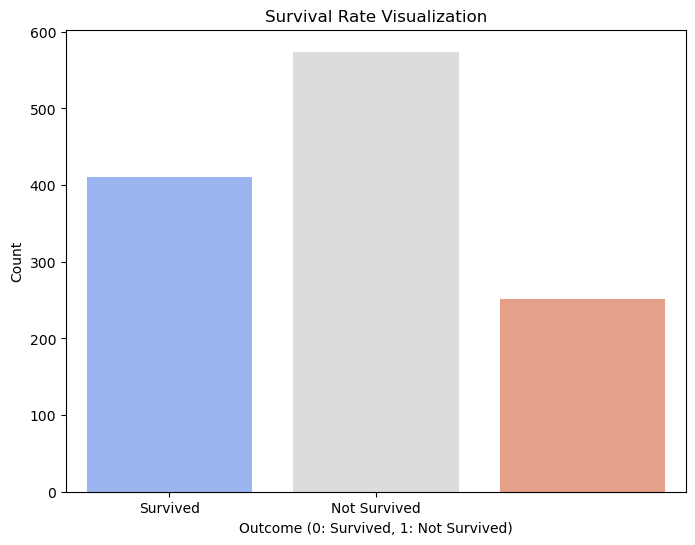

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a count plot for the 'outcome' column
plt.figure(figsize=(8, 6))
sns.countplot(data=train, x="outcome", palette="coolwarm")
plt.title("Survival Rate Visualization")
plt.xlabel("Outcome (0: Survived, 1: Not Survived)")
plt.ylabel("Count")
plt.xticks([0, 1], ["Survived", "Not Survived"])
plt.show()


In [42]:
# Identify categorical (object) columns in both train and test datasets
object_columns_train = train.select_dtypes(include=['object']).columns
object_columns_test = test.select_dtypes(include=['object']).columns

# Apply One-Hot Encoding to the categorical columns
train_encoded_ = pd.get_dummies(train, columns=object_columns_train, drop_first=True)
test_encoded_ = pd.get_dummies(test, columns=object_columns_test, drop_first=True)

# Align the two datasets to ensure they have the same columns
train_encoded, test_encoded = train_encoded_.align(test_encoded_, join='outer', axis=1, fill_value=0)


In [46]:
differet = set(train_encoded.columns).symmetric_difference(set(test_encoded.columns))
print("\n".join(differet))

In [48]:
test_encoded=test_encoded.drop('outcome',axis=1) 

In [52]:
x=train_encoded.drop('outcome',axis=1)
y=train_encoded['outcome']

In [56]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, 
                              AdaBoostClassifier, ExtraTreesClassifier, 
                              BaggingClassifier)
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split

def all_classification(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'Extra Trees': ExtraTreesClassifier(random_state=42),
        'Bagging': BaggingClassifier(random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Logistic Regression': LogisticRegression(random_state=42),
        'SVC': SVC(random_state=42),
        'XGBoost': XGBClassifier(random_state=42),
        'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    }
    
    for name, model in models.items():
        model.fit(X_train, y_train)  # Fit the model
        y_pred = model.predict(X_test)  # Make predictions
        
        print(name)
        print(classification_report(y_test, y_pred))
        print(confusion_matrix(y_test, y_pred))
        print("------------------------------------")

all_classification(x,y)

Random Forest
              precision    recall  f1-score   support

           0       0.61      0.71      0.65        72
           1       0.75      0.76      0.76       121
           2       0.73      0.56      0.63        54

    accuracy                           0.70       247
   macro avg       0.70      0.67      0.68       247
weighted avg       0.71      0.70      0.70       247

[[51 18  3]
 [21 92  8]
 [12 12 30]]
------------------------------------
Gradient Boosting
              precision    recall  f1-score   support

           0       0.62      0.72      0.67        72
           1       0.75      0.75      0.75       121
           2       0.83      0.65      0.73        54

    accuracy                           0.72       247
   macro avg       0.73      0.71      0.72       247
weighted avg       0.73      0.72      0.72       247

[[52 19  1]
 [24 91  6]
 [ 8 11 35]]
------------------------------------
AdaBoost
              precision    recall  f1-score   sup

+ the best model is gradient boosting

In [61]:
from sklearn.ensemble import GradientBoostingClassifier
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model= GradientBoostingClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [63]:
test_prediction=model.predict(test_encoded)

In [67]:
sam = pd.read_csv("sample_submission.csv")
sam['outcome'] = test_prediction
sam['outcome'] = sam['outcome'].map({1: 'lived', 0: 'dead', 2: 'euthanized'})
sam['outcome'] = sam['outcome'].astype(object)

sam.to_csv('prediction.csv', index=False)

### Conclusion

In this study, various machine learning models were tested to predict horse health outcomes.

Top Performers: Gradient Boosting and XGBoost achieved the highest accuracy of 0.72, offering a good balance of precision, recall, and f1-score.
Weakest Model: SVC had the lowest performance with an accuracy of 0.49.
Other Notable Models: Random Forest, AdaBoost, and LightGBM showed promising results with accuracies ranging from 0.70 to 0.72.
Despite strong model performances, the Kaggle score of 0.50609 indicates room for improvement, suggesting that further tuning and feature engineering may enhance results.

Overall, Gradient Boosting and XGBoost are the best models, but optimization is needed to improve the Kaggle score.